# Federated Learning for Multimodal Lung Cancer Subtyping

## Overview
This project implements a **federated learning (FL)** framework to classify lung cancer subtypes **Lung Adecarcinoma (LUAD)** and **Lung Squamous Cell Carcinoma (LUSC)** using multimodal biomedical data.

Unlike traditional centralized machine learning, federated learning enables model training **across multiple descentralized datasets (clients)** without sharing raw data, making it suitable for **privacy-sensitive medical applications**

## Objectives
The goals of this project are to:

- Simulate a federated learning environment with multiple clients
- Train models on **distributed multimodal data** without centralizing it
- Compare performance under:
    - **IID (Homogeneous)** data distribution
    - **Non-IID (Heterogeneous)** data distribution
- Evaluate the impact of:
    - **FedAvg** (baseline federated algorithm)
    - **FedProx** (robust variant for non-IID settings)

## Data modalities
Each modality is processes independently and used as input to the federated pipeline:

- **RNA-Seq** → PCA-reduced gene expression features
- **DNA methylation** → PCA-reduced CpG features
- **WSI (Whole Slide Images)** → Deep feature embeddings from the *MahmoodLab/UNI* ViT encoder (loaded from *Hugging Face Hub* via timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True)), aggregated into fixed-length representations for federated learning
- **Clinical data** → Scaled numerical + one-hot encoded cateforical features

Each sample corresponds to a **patient** and all modalities are aligned using patient IDs

## Significance
The project demonstrates how federated learning can be applied to **multimodal cancer data**, addressing key challenges in:

- Data privacy sharing restrictions
- Heterogeneity across medical institutions
- Scalable and distributed AI in healthcare

In [1]:
import os, random
import numpy as np
from pathlib import Path

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# Load modality data

In [2]:
BASE = Path("/home/steps4growth/gmriechi/Lung-Cancer-Subtyping/Data/02_preprocessed")

PATHS = {
    "rna": {
        "train_X": BASE / "rna" / "rna_train_pca.npy",
        "test_X":  BASE / "rna" / "rna_test_pca.npy",
        "train_y": BASE / "rna" / "rna_y_train.npy",
        "test_y":  BASE / "rna" / "rna_y_test.npy",
        "train_pid": BASE / "rna" / "rna_train_patient_ids.npy",
        "test_pid":  BASE / "rna" / "rna_test_patient_ids.npy",
    },
    "meth": {
        "train_X": BASE / "methylation" / "meth_train_pca.npy",
        "test_X":  BASE / "methylation" / "meth_test_pca.npy",
        "train_y": BASE / "rna" / "rna_y_train.npy",
        "test_y":  BASE / "rna" / "rna_y_test.npy",
        "train_pid": BASE / "methylation" / "meth_train_patient_ids.npy",
        "test_pid":  BASE / "methylation" / "meth_test_patient_ids.npy",
    },
    "wsi": {
        "train_X": BASE / "wsi" / "wsi_train.npy",
        "test_X":  BASE / "wsi" / "wsi_test.npy",
        "train_y": BASE / "rna" / "rna_y_train.npy",
        "test_y":  BASE / "rna" / "rna_y_test.npy",
        "train_pid": BASE / "wsi" / "wsi_train_patient_ids.npy",
        "test_pid":  BASE / "wsi" / "wsi_test_patient_ids.npy",
    },
    "clin": {
        "train_X": BASE / "clinical" / "clin_train_scaled.npy",
        "test_X":  BASE / "clinical" / "clin_test_scaled.npy",
        "train_y": BASE / "rna" / "rna_y_train.npy",
        "test_y":  BASE / "rna" / "rna_y_test.npy",
        "train_pid": BASE / "rna" / "rna_train_patient_ids.npy",
        "test_pid":  BASE / "rna" / "rna_test_patient_ids.npy",
        "cat_feature_names": BASE / "clinical" / "clin_cat_feature_names.npy",
    },
}

def load_modality(modality: str):
    if modality not in PATHS:
        raise ValueError(f"Unknown modality: {modality}. Choose from {list(PATHS.keys())}")

    p = PATHS[modality]

    # files exist
    for k, v in p.items():
        if k == "cat_feature_names":
            continue
        if not Path(v).exists():
            raise FileNotFoundError(f"Missing file for {modality}: {k} -> {v}")

    X_train = np.load(p["train_X"]).astype(np.float32)
    X_test  = np.load(p["test_X"]).astype(np.float32)
    y_train = np.load(p["train_y"]).astype(np.int64)
    y_test  = np.load(p["test_y"]).astype(np.int64)
    pid_train = np.load(p["train_pid"], allow_pickle=True).astype(str)
    pid_test  = np.load(p["test_pid"],  allow_pickle=True).astype(str)

    return X_train, y_train, X_test, y_test, pid_train, pid_test

MODALITY = "wsi"  

X_train, y_train, X_test, y_test, pid_train, pid_test = load_modality(MODALITY)

print("Loaded modality:", MODALITY)
print("Train X:", X_train.shape, "| Train y:", y_train.shape)
print("Test  X:", X_test.shape,  "| Test  y:", y_test.shape)

print("\nClass counts (train):", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class counts (test) :", dict(zip(*np.unique(y_test,  return_counts=True))))

print("\nExample patient IDs (train):", pid_train[:5])
print("Example patient IDs (test) :", pid_test[:5])

Loaded modality: wsi
Train X: (658, 1024) | Train y: (660,)
Test  X: (165, 1024) | Test  y: (165,)

Class counts (train): {np.int64(0): np.int64(364), np.int64(1): np.int64(296)}
Class counts (test) : {np.int64(0): np.int64(91), np.int64(1): np.int64(74)}

Example patient IDs (train): ['TCGA-78-7537' 'TCGA-58-8387' 'TCGA-34-5927' 'TCGA-O2-A52W'
 'TCGA-56-A5DS']
Example patient IDs (test) : ['TCGA-77-A5G1' 'TCGA-05-5428' 'TCGA-43-5670' 'TCGA-J2-A4AE'
 'TCGA-77-8148']


### Ensure WSI Patient ID Arrays Match Feature Matrix Length

The WSI feature matrix has **658 rows**, but the corresponding `pid_train` array appears to contain **more entries** (e.g., 660).  
This causes index errors during alignment because some patient IDs point to row indices that do not exist in `X_train`.

To fix this safely, we **truncate** the WSI patient ID arrays to match the exact number of feature rows:

- `len(pid_train)` must equal `X_train.shape[0]`
- `len(pid_test)` must equal `X_test.shape[0]`

This does **not** change the WSI data — it only removes extra IDs that have no embeddings.

In [3]:
# Ensure pid arrays match X rows for WSI (prevents invalid index mappings)

if len(pid_train) != X_train.shape[0]:
    print(f"pid_train length {len(pid_train)} != X_train rows {X_train.shape[0]} → truncating pid_train")
    pid_train = pid_train[: X_train.shape[0]]

if len(pid_test) != X_test.shape[0]:
    print(f"pid_test length {len(pid_test)} != X_test rows {X_test.shape[0]} → truncating pid_test")
    pid_test = pid_test[: X_test.shape[0]]

print("After trimming (WSI only):")
print("Train:", X_train.shape, len(pid_train))
print("Test :", X_test.shape,  len(pid_test))

pid_train length 660 != X_train rows 658 → truncating pid_train
After trimming (WSI only):
Train: (658, 1024) 658
Test : (165, 1024) 165


### Align Labels to WSI Patients (Keep the 658 Patients With Embeddings)

Since **two patients are missing WSI embeddings**, we will use the WSI patient list as the source of truth.

We:
1. Load the global label patient IDs and labels (from the RNA split files)
2. Create a mapping from patient ID → label
3. Filter the labels to include **only patients that exist in WSI**
4. Ensure that `X_train`, `y_train`, and `pid_train` are perfectly aligned

After this step:

- `X_train.shape[0] == len(y_train) == len(pid_train)` will be **658**
- The same alignment is enforced for the test set

In [4]:
# Load label patient IDs (global split) + labels
label_pid_train = np.load(PATHS["rna"]["train_pid"], allow_pickle=True).astype(str)
label_pid_test  = np.load(PATHS["rna"]["test_pid"],  allow_pickle=True).astype(str)

# Build maps: patient_id -> label
train_label_map = {p: int(y) for p, y in zip(label_pid_train, y_train)}
test_label_map  = {p: int(y) for p, y in zip(label_pid_test,  y_test)}

# Filter to only patients that exist in WSI
train_keep_mask = np.array([p in train_label_map for p in pid_train])
test_keep_mask  = np.array([p in test_label_map  for p in pid_test])

X_train = X_train[train_keep_mask]
pid_train = pid_train[train_keep_mask]
y_train = np.array([train_label_map[p] for p in pid_train], dtype=np.int64)

X_test = X_test[test_keep_mask]
pid_test = pid_test[test_keep_mask]
y_test = np.array([test_label_map[p] for p in pid_test], dtype=np.int64)

print("Final aligned dataset (WSI):")
print("Train X:", X_train.shape, "| Train y:", y_train.shape, "| Train pid:", pid_train.shape)
print("Test  X:", X_test.shape,  "| Test  y:", y_test.shape,  "| Test pid:", pid_test.shape)

print("\nClass counts (train):", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class counts (test) :", dict(zip(*np.unique(y_test,  return_counts=True))))

Final aligned dataset (WSI):
Train X: (658, 1024) | Train y: (658,) | Train pid: (658,)
Test  X: (165, 1024) | Test  y: (165,) | Test pid: (165,)

Class counts (train): {np.int64(0): np.int64(363), np.int64(1): np.int64(295)}
Class counts (test) : {np.int64(0): np.int64(91), np.int64(1): np.int64(74)}


## Partition the Training Data into Federated Clients (IID and Non-IID)

Federated learning assumes training data is distributed across multiple clients (e.g., hospitals or institutions).
In this project, we simulate that setting by splitting the **training set** into `K` clients.

We create two partitioning schemes:

### (A) IID (Stratified) Split
- Data is shuffled and split across clients
- Each client has approximately the **same class distribution** as the global dataset  
- This represents a relatively homogeneous federation

### (B) Non-IID (Dirichlet Label-Skew) Split
- Each client receives a biased subset of labels
- The level of heterogeneity is controlled by a **Dirichlet parameter α**
  - smaller α (e.g., 0.1–0.5) → more skew (more heterogeneous)
  - larger α (e.g., 1–10) → closer to IID

At the end of this step, we will have:
- `clients[client_id] = (X_client, y_client)`
- A printed table showing each client’s sample size and class distribution

In [5]:
from typing import Dict, Tuple

def summarize_clients(clients: Dict[int, Tuple[np.ndarray, np.ndarray]]):
    print("\nClient summary:")
    print("client | n_samples | class0 | class1 | %class1")
    print("-" * 50)
    total = 0
    for cid in sorted(clients.keys()):
        Xc, yc = clients[cid]
        n = len(yc)
        total += n
        c0 = int(np.sum(yc == 0))
        c1 = int(np.sum(yc == 1))
        pct1 = (c1 / n * 100) if n > 0 else 0.0
        print(f"{cid:>6} | {n:>9} | {c0:>6} | {c1:>6} | {pct1:>6.2f}%")
    print("-" * 50)
    print("Total samples across clients:", total)

def make_iid_stratified_clients(X: np.ndarray, y: np.ndarray, num_clients: int, seed: int = 42):
    """
    Stratified IID split: distribute class 0 and class 1 evenly across clients.
    """
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    rng.shuffle(idx0)
    rng.shuffle(idx1)

    # split each class indices into num_clients chunks
    splits0 = np.array_split(idx0, num_clients)
    splits1 = np.array_split(idx1, num_clients)

    clients = {}
    for cid in range(num_clients):
        idx = np.concatenate([splits0[cid], splits1[cid]])
        rng.shuffle(idx)
        clients[cid] = (X[idx], y[idx])
    return clients

def make_non_iid_dirichlet_clients(X: np.ndarray, y: np.ndarray, num_clients: int, alpha: float, seed: int = 42):
    """
    Non-IID split using Dirichlet label-skew.
    For each class, distribute its samples across clients according to Dirichlet(alpha).
    """
    rng = np.random.default_rng(seed)
    classes = np.unique(y)

    # collect indices per class
    class_indices = {c: np.where(y == c)[0] for c in classes}
    for c in classes:
        rng.shuffle(class_indices[c])

    # proportions per class per client
    client_indices = {cid: [] for cid in range(num_clients)}

    for c in classes:
        idx = class_indices[c]
        n_c = len(idx)

        proportions = rng.dirichlet([alpha] * num_clients)
        # convert proportions to counts that sum to n_c
        counts = (proportions * n_c).astype(int)

        # adjust counts to ensure sum == n_c
        diff = n_c - counts.sum()
        if diff > 0:
            # add remaining samples to clients with largest proportions
            for i in np.argsort(-proportions)[:diff]:
                counts[i] += 1
        elif diff < 0:
            # remove extras from clients with largest counts
            for i in np.argsort(-counts)[:abs(diff)]:
                counts[i] -= 1

        start = 0
        for cid in range(num_clients):
            take = counts[cid]
            if take > 0:
                client_indices[cid].extend(idx[start:start+take].tolist())
            start += take

    clients = {}
    for cid in range(num_clients):
        idx = np.array(client_indices[cid], dtype=int)
        rng.shuffle(idx)
        clients[cid] = (X[idx], y[idx])
    return clients

## Define Helper Functions for Federated Client Splits

In this step, we define utility functions needed for the federated learning setup:

### What we create
- A function to **summarize client datasets** (samples per client + class distribution)
- A function to create an **IID (stratified) split**
  - Each client has a similar label distribution to the global training set
- A function to create a **Non-IID split using Dirichlet label-skew**
  - Clients have different label proportions controlled by Dirichlet parameter `α`

These functions will be reused across experiments (different numbers of clients, different α values).

In [6]:
from typing import Dict, Tuple

def summarize_clients(clients: Dict[int, Tuple[np.ndarray, np.ndarray]]):
    print("\nClient summary:")
    print("client | n_samples | class0 | class1 | %class1")
    print("-" * 55)
    total = 0
    for cid in sorted(clients.keys()):
        Xc, yc = clients[cid]
        n = len(yc)
        total += n
        c0 = int(np.sum(yc == 0))
        c1 = int(np.sum(yc == 1))
        pct1 = (c1 / n * 100) if n > 0 else 0.0
        print(f"{cid:>6} | {n:>9} | {c0:>6} | {c1:>6} | {pct1:>7.2f}%")
    print("-" * 55)
    print("Total samples across clients:", total)

def make_iid_stratified_clients(X: np.ndarray, y: np.ndarray, num_clients: int, seed: int = 42):
    """
    Stratified IID split: distribute class 0 and class 1 evenly across clients.
    """
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    rng.shuffle(idx0)
    rng.shuffle(idx1)

    splits0 = np.array_split(idx0, num_clients)
    splits1 = np.array_split(idx1, num_clients)

    clients = {}
    for cid in range(num_clients):
        idx = np.concatenate([splits0[cid], splits1[cid]])
        rng.shuffle(idx)
        clients[cid] = (X[idx], y[idx])
    return clients

def make_non_iid_dirichlet_clients(X: np.ndarray, y: np.ndarray, num_clients: int, alpha: float, seed: int = 42):
    """
    Non-IID split using Dirichlet label-skew.
    For each class, distribute its samples across clients according to Dirichlet(alpha).
    """
    rng = np.random.default_rng(seed)
    classes = np.unique(y)

    class_indices = {c: np.where(y == c)[0] for c in classes}
    for c in classes:
        rng.shuffle(class_indices[c])

    client_indices = {cid: [] for cid in range(num_clients)}

    for c in classes:
        idx = class_indices[c]
        n_c = len(idx)

        proportions = rng.dirichlet([alpha] * num_clients)
        counts = (proportions * n_c).astype(int)

        diff = n_c - counts.sum()
        if diff > 0:
            for i in np.argsort(-proportions)[:diff]:
                counts[i] += 1
        elif diff < 0:
            for i in np.argsort(-counts)[:abs(diff)]:
                counts[i] -= 1

        start = 0
        for cid in range(num_clients):
            take = counts[cid]
            if take > 0:
                client_indices[cid].extend(idx[start:start+take].tolist())
            start += take

    clients = {}
    for cid in range(num_clients):
        idx = np.array(client_indices[cid], dtype=int)
        rng.shuffle(idx)
        clients[cid] = (X[idx], y[idx])
    return clients

### Create IID Federated Clients (Stratified)

We now create an IID federated setup by splitting the global training set into `K` clients
while preserving the overall class balance in each client.

This serves as the baseline federated learning scenario.

In [7]:
K = 5  # number of clients (we will test other values later)

clients_iid = make_iid_stratified_clients(X_train, y_train, num_clients=K, seed=42)

print("IID client split created.")
summarize_clients(clients_iid)

IID client split created.

Client summary:
client | n_samples | class0 | class1 | %class1
-------------------------------------------------------
     0 |       132 |     73 |     59 |   44.70%
     1 |       132 |     73 |     59 |   44.70%
     2 |       132 |     73 |     59 |   44.70%
     3 |       131 |     72 |     59 |   45.04%
     4 |       131 |     72 |     59 |   45.04%
-------------------------------------------------------
Total samples across clients: 658


### Create Non-IID Federated Clients (Dirichlet Label-Skew)

Next, we simulate a heterogeneous (non-IID) federation where client data distributions differ.

We use Dirichlet label-skew with parameter `α`:
- Smaller `α` → more skewed clients (more heterogeneous)
- Larger `α` → closer to IID

We start with `α = 0.5` (moderate heterogeneity).

In [8]:
alpha = 0.5

clients_noniid = make_non_iid_dirichlet_clients(X_train, y_train, num_clients=K, alpha=alpha, seed=42)

print(f"Non-IID client split created (Dirichlet alpha={alpha}).")
summarize_clients(clients_noniid)

Non-IID client split created (Dirichlet alpha=0.5).

Client summary:
client | n_samples | class0 | class1 | %class1
-------------------------------------------------------
     0 |       143 |    125 |     18 |   12.59%
     1 |       212 |    167 |     45 |   21.23%
     2 |       112 |      7 |    105 |   93.75%
     3 |        99 |     59 |     40 |   40.40%
     4 |        92 |      5 |     87 |   94.57%
-------------------------------------------------------
Total samples across clients: 658


## Define the Local Model (MLP) for Federated Learning

In federated learning, **all clients share the same model architecture**.

Each communication round:
1. The server sends the current **global model weights** to participating clients
2. Each client trains the model locally on its private data for a few epochs
3. Clients send updated weights back to the server
4. The server aggregates updates (FedAvg / FedProx)

For this study, we use a simple and reproducible **MLP** (Multi-Layer Perceptron) for binary classification (LUAD vs LUSC):

- Input: WSI embedding vector (1024 features)
- Dense layers with ReLU activations
- Dropout for regularization
- Output: sigmoid probability for class 1

This is intentionally lightweight and paper-friendly, and it works well for fixed-length embedding inputs.

In [9]:
import tensorflow as tf

def build_mlp(input_dim: int, lr: float = 1e-3, dropout: float = 0.2):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

input_dim = X_train.shape[1]
global_model = build_mlp(input_dim=input_dim, lr=1e-3, dropout=0.2)

print("Global model initialized.")
global_model.summary()

2026-02-22 10:37:53.632893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Global model initialized.


W0000 00:00:1771774676.290582 1326528 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,913 (1.06 MB)

 Trainable params: 278,913 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

### Convert Each Client’s Data Into TensorFlow Datasets

To ensure efficient mini-batch training on each client, we convert each client's `(X, y)` arrays into
`tf.data.Dataset` pipelines that support:

- Shuffling (client-local)
- Batching
- Prefetching for speed

We will create datasets for both:
- IID client split (`clients_iid`)
- Non-IID client split (`clients_noniid`)

These datasets will be fed into the local training step in federated rounds.

In [10]:
def make_tf_dataset(X: np.ndarray, y: np.ndarray, batch_size: int = 32, shuffle: bool = True, seed: int = 42):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_client_datasets(clients: Dict[int, Tuple[np.ndarray, np.ndarray]], batch_size: int = 32):
    client_ds = {}
    client_sizes = {}
    for cid, (Xc, yc) in clients.items():
        client_ds[cid] = make_tf_dataset(Xc, yc, batch_size=batch_size, shuffle=True, seed=42)
        client_sizes[cid] = len(yc)
    return client_ds, client_sizes

BATCH_SIZE = 32

client_ds_iid, client_sizes_iid = build_client_datasets(clients_iid, batch_size=BATCH_SIZE)
client_ds_noniid, client_sizes_noniid = build_client_datasets(clients_noniid, batch_size=BATCH_SIZE)

print("Client datasets created.")
print("IID client sizes:", client_sizes_iid)
print("Non-IID client sizes:", client_sizes_noniid)

Client datasets created.
IID client sizes: {0: 132, 1: 132, 2: 132, 3: 131, 4: 131}
Non-IID client sizes: {0: 143, 1: 212, 2: 112, 3: 99, 4: 92}


## Federated Training With FedAvg (Server–Client Simulation)

In this step, we implement the core federated learning procedure using **Federated Averaging (FedAvg)**.

### What happens in each communication round:
1. The server selects participating clients (all clients for now)
2. The server sends the current **global model weights**
3. Each client:
   - loads the global weights
   - trains locally for `E` epochs on its private dataset
   - returns updated weights to the server
4. The server aggregates client weights using **weighted averaging**
   - clients with more samples contribute more
5. The updated global model is evaluated on the **held-out global test set**

We track performance across rounds:
- Test loss
- Test accuracy
- Test ROC-AUC

This produces learning curves suitable for reporting in a paper.

In [11]:
def get_model_weights(model: tf.keras.Model):
    return model.get_weights()

def set_model_weights(model: tf.keras.Model, weights):
    model.set_weights(weights)

def fedavg_aggregate(client_weights: list, client_sizes: list):
    """
    Weighted average of model weights across clients.
    client_weights: list of weights (each item is a list of numpy arrays)
    client_sizes: list of sample counts per client
    """
    total = np.sum(client_sizes)
    new_weights = []
    for weights_tuple in zip(*client_weights):
        # weights_tuple is a tuple of arrays, one per client, for the same layer
        layer_avg = np.zeros_like(weights_tuple[0], dtype=np.float32)
        for w, n in zip(weights_tuple, client_sizes):
            layer_avg += (n / total) * w.astype(np.float32)
        new_weights.append(layer_avg)
    return new_weights

### Define the Local Client Training Procedure

Each client receives the current global weights and performs local training for a small number of epochs.
After local training, the client returns its updated weights back to the server.

To keep the experiment controlled and reproducible:
- Each client uses the same model architecture and optimizer configuration
- Each client trains for the same number of local epochs

In [12]:
def local_train(global_weights, client_dataset, input_dim: int, lr: float, dropout: float, local_epochs: int):
    # Create a fresh model (client-side), load global weights, train locally
    model = build_mlp(input_dim=input_dim, lr=lr, dropout=dropout)
    set_model_weights(model, global_weights)

    model.fit(client_dataset, epochs=local_epochs, verbose=0)
    return get_model_weights(model)

### Run FedAvg for Multiple Rounds and Evaluate the Global Model Each Round

We now execute the full federated learning process for `R` communication rounds.

For each round:
- collect updated weights from all clients
- aggregate weights using FedAvg
- update the global model
- evaluate the global model on the held-out test set

We store the results per round to later plot learning curves.

In [13]:
def evaluate_global(model: tf.keras.Model, X_test: np.ndarray, y_test: np.ndarray):
    # Keras evaluate gives loss + compiled metrics
    loss, acc, auc = model.evaluate(X_test, y_test, verbose=0)
    return float(loss), float(acc), float(auc)

def run_fedavg(
    clients_ds: Dict[int, tf.data.Dataset],
    clients_sizes: Dict[int, int],
    X_test: np.ndarray,
    y_test: np.ndarray,
    rounds: int = 30,
    local_epochs: int = 1,
    lr: float = 1e-3,
    dropout: float = 0.2
):
    input_dim = X_test.shape[1]
    global_model = build_mlp(input_dim=input_dim, lr=lr, dropout=dropout)
    global_weights = get_model_weights(global_model)

    history = {"round": [], "loss": [], "acc": [], "auc": []}

    client_ids = sorted(clients_ds.keys())

    for r in range(1, rounds + 1):
        client_weights = []
        client_ns = []

        for cid in client_ids:
            w = local_train(
                global_weights=global_weights,
                client_dataset=clients_ds[cid],
                input_dim=input_dim,
                lr=lr,
                dropout=dropout,
                local_epochs=local_epochs
            )
            client_weights.append(w)
            client_ns.append(clients_sizes[cid])

        # FedAvg aggregation
        global_weights = fedavg_aggregate(client_weights, client_ns)
        set_model_weights(global_model, global_weights)

        # Evaluate global model
        loss, acc, auc = evaluate_global(global_model, X_test, y_test)

        history["round"].append(r)
        history["loss"].append(loss)
        history["acc"].append(acc)
        history["auc"].append(auc)

        print(f"Round {r:02d}/{rounds} | loss={loss:.4f} | acc={acc:.4f} | auc={auc:.4f}")

    return global_model, history

### Train With FedAvg Under IID Clients (Baseline)

We first run FedAvg using the IID (stratified) client split as a baseline.
This establishes expected performance when client data distributions are similar.

We will use:
- `K = 5` clients
- `R = 30` rounds
- `E = 1` local epoch per round

In [14]:
ROUNDS = 30
LOCAL_EPOCHS = 1

global_model_iid, hist_iid = run_fedavg(
    clients_ds=client_ds_iid,
    clients_sizes=client_sizes_iid,
    X_test=X_test,
    y_test=y_test,
    rounds=ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    lr=1e-3,
    dropout=0.2
)

Round 01/30 | loss=0.6030 | acc=0.6909 | auc=0.8038
Round 02/30 | loss=0.5644 | acc=0.7212 | auc=0.8271
Round 03/30 | loss=0.5295 | acc=0.7636 | auc=0.8857
Round 04/30 | loss=0.5113 | acc=0.8000 | auc=0.8894
Round 05/30 | loss=0.4812 | acc=0.8242 | auc=0.8989
Round 06/30 | loss=0.4873 | acc=0.8242 | auc=0.8914
Round 07/30 | loss=0.4684 | acc=0.8485 | auc=0.8997
Round 08/30 | loss=0.4571 | acc=0.8061 | auc=0.8995
Round 09/30 | loss=0.4311 | acc=0.8424 | auc=0.9114
Round 10/30 | loss=0.4572 | acc=0.8242 | auc=0.9128
Round 11/30 | loss=0.4575 | acc=0.8182 | auc=0.8907
Round 12/30 | loss=0.4433 | acc=0.8242 | auc=0.9021
Round 13/30 | loss=0.4659 | acc=0.7939 | auc=0.8920
Round 14/30 | loss=0.4274 | acc=0.8182 | auc=0.9004
Round 15/30 | loss=0.4365 | acc=0.8121 | auc=0.8948
Round 16/30 | loss=0.4631 | acc=0.7939 | auc=0.8946
Round 17/30 | loss=0.4793 | acc=0.7697 | auc=0.8871
Round 18/30 | loss=0.4616 | acc=0.7818 | auc=0.8906
Round 19/30 | loss=0.4486 | acc=0.7879 | auc=0.8894
Round 20/30 

## Visualize Federated Learning Performance Across Rounds

To better understand training dynamics, we plot learning curves across communication rounds:

- **Loss vs Rounds**
- **Accuracy vs Rounds**
- **ROC-AUC vs Rounds**

These plots help us:
- Identify convergence behavior
- Detect instability or overfitting
- Compare IID vs Non-IID performance later

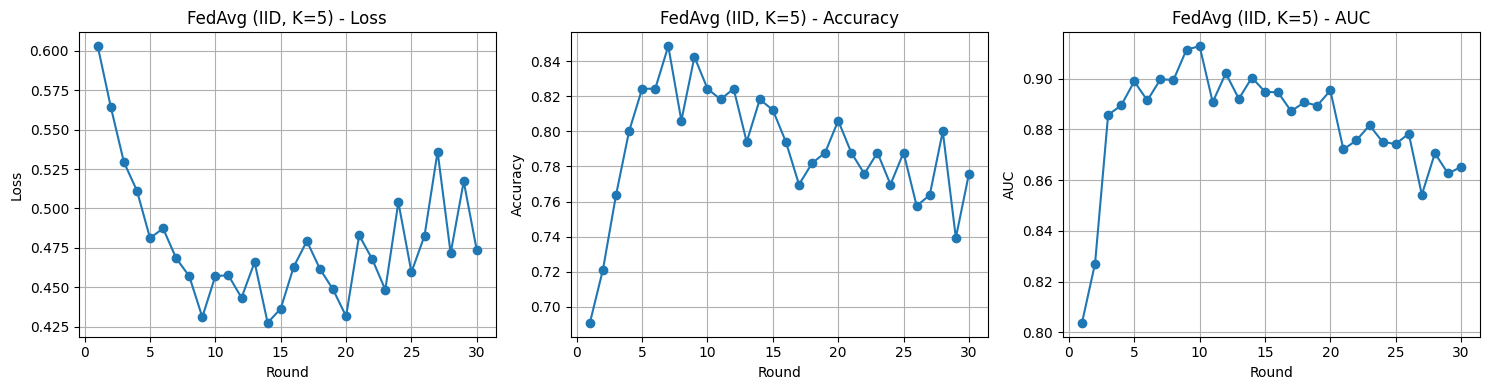

In [15]:
import matplotlib.pyplot as plt 

rounds = hist_iid["round"]

plt.figure(figsize=(15, 4))

# Loss
plt.subplot(1, 3, 1)
plt.plot(rounds, hist_iid["loss"], marker="o")
plt.title("FedAvg (IID, K=5) - Loss")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, hist_iid["acc"], marker="o")
plt.title("FedAvg (IID, K=5) - Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)

# AUC
plt.subplot(1, 3, 3)
plt.plot(rounds, hist_iid["auc"], marker="o")
plt.title("FedAvg (IID, K=5) - AUC")
plt.xlabel("Round")
plt.ylabel("AUC")
plt.grid(True)

plt.tight_layout()
plt.show()

### Final Evaluation (FedAvg, IID, K=5)

After federated training, we evaluate the **final global model** on the held-out test set.

We report:
- **Confusion Matrix** (TP/FP/TN/FN)
- **ROC Curve** and **AUC**
- (Optional) threshold-based predicted labels at 0.5

This provides standard biomedical classification evaluation outputs.

Confusion Matrix (rows=true, cols=pred):
[[70 21]
 [16 58]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8140    0.7692    0.7910        91
           1     0.7342    0.7838    0.7582        74

    accuracy                         0.7758       165
   macro avg     0.7741    0.7765    0.7746       165
weighted avg     0.7782    0.7758    0.7763       165



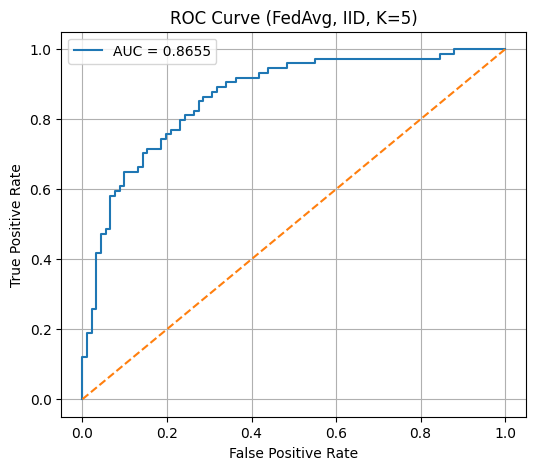


Test AUC: 0.8655


In [16]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Predict probabilities and labels
y_prob = global_model_iid.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows=true, cols=pred):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (FedAvg, IID, K=5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

print(f"\nTest AUC: {roc_auc:.4f}")

## STrain FedAvg Under Non-IID Clients (K=5, Dirichlet α=0.5)

We now repeat the same federated learning experiment under a **non-IID** client distribution.

Client data heterogeneity is simulated using Dirichlet label-skew (α = 0.5), which produces
clients with very different class distributions.

We train using the same setup:
- K = 5 clients
- R = 30 rounds
- E = 1 local epoch per round
- FedAvg aggregation

We then evaluate the final global model on the same held-out test set.

In [17]:
# Build tf.data datasets for non-IID clients
client_ds_noniid, client_sizes_noniid = build_client_datasets(clients_noniid, batch_size=32)

# Train FedAvg under non-IID
global_model_noniid, hist_noniid = run_fedavg(
    clients_ds=client_ds_noniid,
    clients_sizes=client_sizes_noniid,
    X_test=X_test,
    y_test=y_test,
    rounds=30,
    local_epochs=1,
    lr=1e-3,
    dropout=0.2
)

Round 01/30 | loss=0.7659 | acc=0.4788 | auc=0.7074
Round 02/30 | loss=0.6123 | acc=0.6121 | auc=0.8179


Round 03/30 | loss=0.6017 | acc=0.7636 | auc=0.8192
Round 04/30 | loss=0.5565 | acc=0.7758 | auc=0.8329
Round 05/30 | loss=0.5383 | acc=0.7818 | auc=0.8512
Round 06/30 | loss=0.5501 | acc=0.8061 | auc=0.8377
Round 07/30 | loss=0.5186 | acc=0.7939 | auc=0.8597
Round 08/30 | loss=0.5216 | acc=0.8061 | auc=0.8595
Round 09/30 | loss=0.5125 | acc=0.7879 | auc=0.8632
Round 10/30 | loss=0.4887 | acc=0.8242 | auc=0.8847
Round 11/30 | loss=0.4839 | acc=0.8061 | auc=0.8905
Round 12/30 | loss=0.4899 | acc=0.7939 | auc=0.8671
Round 13/30 | loss=0.4721 | acc=0.8121 | auc=0.8785
Round 14/30 | loss=0.4841 | acc=0.8303 | auc=0.8661
Round 15/30 | loss=0.5081 | acc=0.7758 | auc=0.8620
Round 16/30 | loss=0.4860 | acc=0.7879 | auc=0.8639
Round 17/30 | loss=0.5067 | acc=0.8121 | auc=0.8634
Round 18/30 | loss=0.4719 | acc=0.8182 | auc=0.8630
Round 19/30 | loss=0.4948 | acc=0.7939 | auc=0.8518
Round 20/30 | loss=0.5129 | acc=0.7818 | auc=0.8511
Round 21/30 | loss=0.4989 | acc=0.8000 | auc=0.8452
Round 22/30 

## Plot Learning Curves (FedAvg, Non-IID, K=5)

We visualize the training behavior under a non-IID client distribution.

These plots highlight:
- Slower convergence
- Increased instability
- Performance degradation compared to IID

This comparison is critical for understanding the challenges of federated learning in real-world medical data.

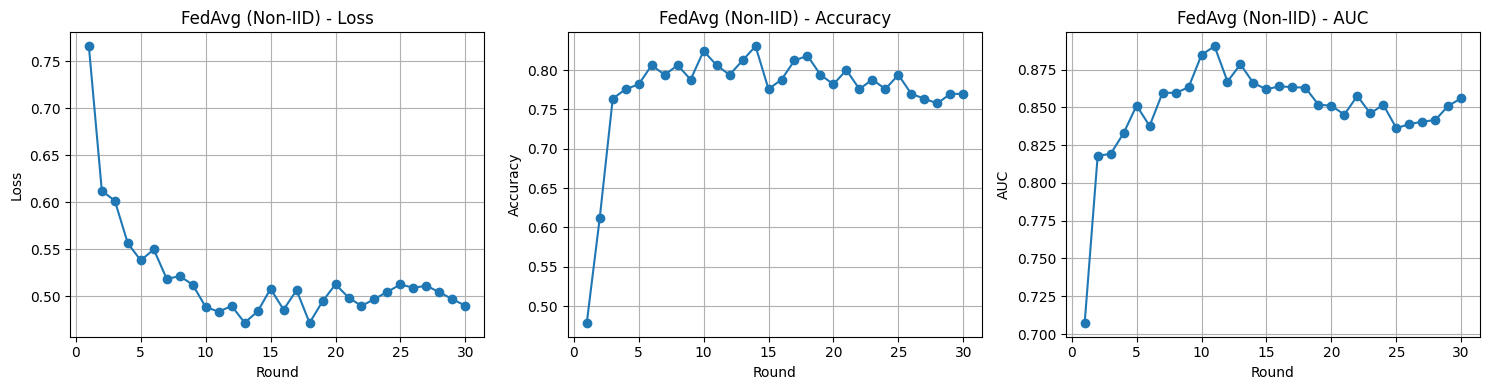

In [18]:
rounds = hist_noniid["round"]

plt.figure(figsize=(15, 4))

# Loss
plt.subplot(1, 3, 1)
plt.plot(rounds, hist_noniid["loss"], marker='o')
plt.title("FedAvg (Non-IID) - Loss")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, hist_noniid["acc"], marker='o')
plt.title("FedAvg (Non-IID) - Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid()

# AUC
plt.subplot(1, 3, 3)
plt.plot(rounds, hist_noniid["auc"], marker='o')
plt.title("FedAvg (Non-IID) - AUC")
plt.xlabel("Round")
plt.ylabel("AUC")
plt.grid()

plt.tight_layout()
plt.show()

## Final Evaluation (FedAvg, Non-IID, K=5)

We evaluate the final global model trained under non-IID conditions.

Metrics:
- Confusion Matrix
- Classification Report
- ROC Curve and AUC

This allows direct comparison with the IID setting.

Confusion Matrix:
[[65 26]
 [12 62]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8442    0.7143    0.7738        91
           1     0.7045    0.8378    0.7654        74

    accuracy                         0.7697       165
   macro avg     0.7744    0.7761    0.7696       165
weighted avg     0.7815    0.7697    0.7701       165



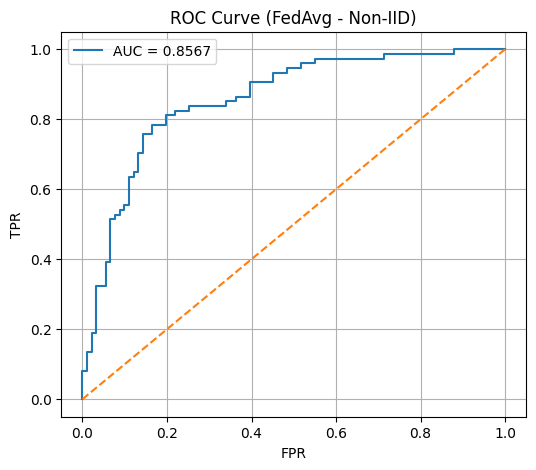


Final AUC (Non-IID): 0.8567


In [19]:
# Predictions
y_prob = global_model_noniid.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve (FedAvg - Non-IID)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

print(f"\nFinal AUC (Non-IID): {roc_auc:.4f}")

## Train With FedProx Under Non-IID Clients (K=5)

FedAvg can become unstable under non-IID data because local client updates drift away from the global solution.

**FedProx** addresses this by adding a proximal term to the local client objective:

\[
\min_w \; f_k(w) + \frac{\mu}{2}\|w - w^{(t)}\|^2
\]

Where:
- \(f_k(w)\) is the client’s local loss
- \(w^{(t)}\) are the current global weights
- \(\mu\) controls how strongly the client is penalized for drifting

We keep the same setup as before:
- K = 5 clients
- R = 30 rounds
- E = 1 local epoch per round

We will compare FedProx to FedAvg under the same non-IID split.

In [20]:
# FedProx local training (client-side)

bce = tf.keras.losses.BinaryCrossentropy()

def fedprox_local_train(
    global_weights,
    client_dataset,
    input_dim: int,
    lr: float = 1e-3,
    dropout: float = 0.2,
    local_epochs: int = 1,
    mu: float = 1e-2,
):
    """
    Train one client model with FedProx:
    loss = BCE + (mu/2) * ||w - w_global||^2
    """
    model = build_mlp(input_dim=input_dim, lr=lr, dropout=dropout)
    model.set_weights(global_weights)

    # Convert global weights to tensors for proximal term
    w_global = [tf.constant(w, dtype=tf.float32) for w in global_weights]
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for _ in range(local_epochs):
        for xb, yb in client_dataset:
            xb = tf.cast(xb, tf.float32)
            yb = tf.cast(tf.reshape(yb, (-1, 1)), tf.float32)

            with tf.GradientTape() as tape:
                yhat = model(xb, training=True)
                base_loss = bce(yb, yhat)

                # proximal penalty over trainable variables
                prox = 0.0
                for v, wg in zip(model.trainable_variables, w_global):
                    prox += tf.reduce_sum(tf.square(v - wg))

                loss = base_loss + (mu / 2.0) * prox

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return model.get_weights()

### Run FedProx (Server Aggregation + Per-Round Evaluation)

We now run the full federated procedure using FedProx client updates and FedAvg-style aggregation on the server.

Each round:
- broadcast global weights
- clients train with FedProx penalty (μ)
- server aggregates updates weighted by client sample sizes
- evaluate on the held-out test set

In [21]:
def run_fedprox(
    clients_ds: Dict[int, tf.data.Dataset],
    clients_sizes: Dict[int, int],
    X_test: np.ndarray,
    y_test: np.ndarray,
    rounds: int = 30,
    local_epochs: int = 1,
    lr: float = 1e-3,
    dropout: float = 0.2,
    mu: float = 1e-2
):
    input_dim = X_test.shape[1]
    global_model = build_mlp(input_dim=input_dim, lr=lr, dropout=dropout)
    global_weights = global_model.get_weights()

    history = {"round": [], "loss": [], "acc": [], "auc": []}
    client_ids = sorted(clients_ds.keys())

    for r in range(1, rounds + 1):
        client_weights = []
        client_ns = []

        for cid in client_ids:
            w = fedprox_local_train(
                global_weights=global_weights,
                client_dataset=clients_ds[cid],
                input_dim=input_dim,
                lr=lr,
                dropout=dropout,
                local_epochs=local_epochs,
                mu=mu
            )
            client_weights.append(w)
            client_ns.append(clients_sizes[cid])

        # Server aggregation (same as FedAvg)
        global_weights = fedavg_aggregate(client_weights, client_ns)
        global_model.set_weights(global_weights)

        loss, acc, auc_ = global_model.evaluate(X_test, y_test, verbose=0)
        history["round"].append(r)
        history["loss"].append(float(loss))
        history["acc"].append(float(acc))
        history["auc"].append(float(auc_))

        print(f"Round {r:02d}/{rounds} | loss={loss:.4f} | acc={acc:.4f} | auc={auc_:.4f}")

    return global_model, history

### Execute FedProx on Non-IID Clients (K=5, α=0.5)

We now run FedProx using the same non-IID client split created earlier.
We start with μ = 0.01 (a common default) and can tune it later if needed.

In [22]:
MU = 1e-2  # 0.01

global_model_fedprox, hist_fedprox = run_fedprox(
    clients_ds=client_ds_noniid,
    clients_sizes=client_sizes_noniid,
    X_test=X_test,
    y_test=y_test,
    rounds=30,
    local_epochs=1,
    lr=1e-3,
    dropout=0.2,
    mu=MU
)

2026-02-22 10:42:24.577139: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-22 10:42:24.875297: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-22 10:42:25.270128: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 01/30 | loss=0.5886 | acc=0.7212 | auc=0.8066


2026-02-22 10:42:26.399194: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 02/30 | loss=0.5652 | acc=0.7030 | auc=0.8410
Round 03/30 | loss=0.5487 | acc=0.7333 | auc=0.8544


2026-02-22 10:42:28.280806: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Round 07/30 | loss=0.5139 | acc=0.8000 | auc=0.8628
Round 08/30 | loss=0.5179 | acc=0.7636 | auc=0.8561
Round 09/30 | loss=0.5174 | acc=0.7697 | auc=0.8485
Round 10/30 | loss=0.5027 | acc=0.8121 | auc=0.8649
Round 11/30 | loss=0.4779 | acc=0.8121 | auc=0.8721
Round 12/30 | loss=0.4676 | acc=0.8182 | auc=0.8829


2026-02-22 10:42:39.618683: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 13/30 | loss=0.4777 | acc=0.8061 | auc=0.8697
Round 14/30 | loss=0.5099 | acc=0.8061 | auc=0.8555
Round 15/30 | loss=0.4792 | acc=0.8121 | auc=0.8640
Round 16/30 | loss=0.4841 | acc=0.7818 | auc=0.8688
Round 17/30 | loss=0.4550 | acc=0.8303 | auc=0.8827
Round 18/30 | loss=0.4745 | acc=0.8000 | auc=0.8777
Round 19/30 | loss=0.4776 | acc=0.8000 | auc=0.8753
Round 20/30 | loss=0.4527 | acc=0.8000 | auc=0.8857
Round 21/30 | loss=0.4586 | acc=0.7758 | auc=0.8672
Round 22/30 | loss=0.4672 | acc=0.8121 | auc=0.8646
Round 23/30 | loss=0.4543 | acc=0.8061 | auc=0.8731
Round 24/30 | loss=0.4788 | acc=0.7879 | auc=0.8738
Round 25/30 | loss=0.4797 | acc=0.8000 | auc=0.8545


2026-02-22 10:42:54.765936: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 26/30 | loss=0.4826 | acc=0.7939 | auc=0.8753
Round 27/30 | loss=0.4638 | acc=0.7939 | auc=0.8684
Round 28/30 | loss=0.4875 | acc=0.8061 | auc=0.8626
Round 29/30 | loss=0.4750 | acc=0.8061 | auc=0.8674
Round 30/30 | loss=0.4653 | acc=0.8000 | auc=0.8629


## Compare Training Dynamics (Non-IID) — FedAvg vs FedProx

We compare **FedAvg** and **FedProx** under the same non-IID client split.

We plot:
- Loss vs Round
- Accuracy vs Round
- AUC vs Round

This shows whether FedProx improves stability and overall performance under heterogeneity.

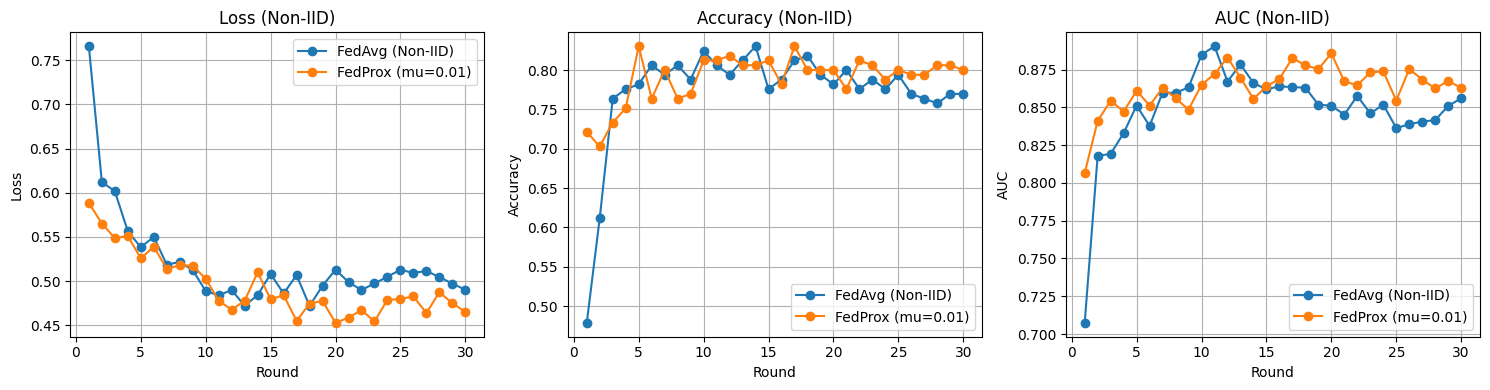

Final (Round 30) metrics:
FedAvg  Non-IID: loss=0.4902, acc=0.7697, auc=0.8560
FedProx Non-IID: loss=0.4653, acc=0.8000, auc=0.8629


In [23]:
rounds = hist_noniid["round"]

plt.figure(figsize=(15, 4))

# Loss comparison
plt.subplot(1, 3, 1)
plt.plot(rounds, hist_noniid["loss"], marker="o", label="FedAvg (Non-IID)")
plt.plot(rounds, hist_fedprox["loss"], marker="o", label=f"FedProx (mu={MU})")
plt.title("Loss (Non-IID)")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Accuracy comparison
plt.subplot(1, 3, 2)
plt.plot(rounds, hist_noniid["acc"], marker="o", label="FedAvg (Non-IID)")
plt.plot(rounds, hist_fedprox["acc"], marker="o", label=f"FedProx (mu={MU})")
plt.title("Accuracy (Non-IID)")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

# AUC comparison
plt.subplot(1, 3, 3)
plt.plot(rounds, hist_noniid["auc"], marker="o", label="FedAvg (Non-IID)")
plt.plot(rounds, hist_fedprox["auc"], marker="o", label=f"FedProx (mu={MU})")
plt.title("AUC (Non-IID)")
plt.xlabel("Round")
plt.ylabel("AUC")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Final (Round 30) metrics:")
print(f"FedAvg  Non-IID: loss={hist_noniid['loss'][-1]:.4f}, acc={hist_noniid['acc'][-1]:.4f}, auc={hist_noniid['auc'][-1]:.4f}")
print(f"FedProx Non-IID: loss={hist_fedprox['loss'][-1]:.4f}, acc={hist_fedprox['acc'][-1]:.4f}, auc={hist_fedprox['auc'][-1]:.4f}")

## Final Test Evaluation (FedProx, Non-IID)

We evaluate the final global model trained with FedProx on the held-out test set.

We report:
- Confusion Matrix
- Classification Report
- ROC Curve and AUC

This makes the comparison with FedAvg complete and publication-ready.

Confusion Matrix (FedProx, Non-IID):
[[78 13]
 [20 54]]

Classification Report (FedProx, Non-IID):
              precision    recall  f1-score   support

           0     0.7959    0.8571    0.8254        91
           1     0.8060    0.7297    0.7660        74

    accuracy                         0.8000       165
   macro avg     0.8009    0.7934    0.7957       165
weighted avg     0.8004    0.8000    0.7987       165



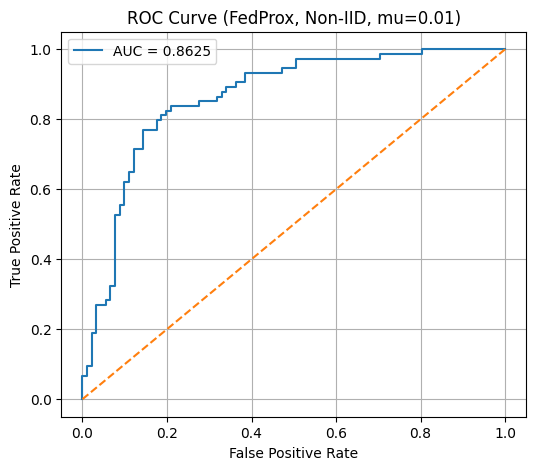


Final Test AUC (FedProx): 0.8625


In [24]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Predict probabilities and labels for FedProx model
y_prob = global_model_fedprox.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (FedProx, Non-IID):")
print(cm)

print("\nClassification Report (FedProx, Non-IID):")
print(classification_report(y_test, y_pred, digits=4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve (FedProx, Non-IID, mu={MU})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

print(f"\nFinal Test AUC (FedProx): {roc_auc:.4f}")

#### Summary Table (Non-IID)

We summarize final test performance for the non-IID setting:

- FedAvg (Non-IID)
- FedProx (Non-IID)

This table can be copied directly into the Results section.

In [25]:
print("Non-IID Final Metrics (Round 30 / Test):")
print(f"FedAvg  : loss={hist_noniid['loss'][-1]:.4f}, acc={hist_noniid['acc'][-1]:.4f}, auc={hist_noniid['auc'][-1]:.4f}")
print(f"FedProx : loss={hist_fedprox['loss'][-1]:.4f}, acc={hist_fedprox['acc'][-1]:.4f}, auc={hist_fedprox['auc'][-1]:.4f}")

Non-IID Final Metrics (Round 30 / Test):
FedAvg  : loss=0.4902, acc=0.7697, auc=0.8560
FedProx : loss=0.4653, acc=0.8000, auc=0.8629


## Run Multiple Client Settings Automatically (K = 2 and K = 10)

Instead of manually repeating the full pipeline, we loop over different numbers of clients.

For each K in {2, 10}, we run:
1. **FedAvg on IID clients**
2. **FedAvg on Non-IID clients (Dirichlet α = 0.5)**
3. **FedProx on Non-IID clients (same α, μ = 0.01)**

We store:
- Per-round histories (loss/acc/auc)
- Final metrics summary table for easy reporting

In [26]:
K_list = [2, 10]       
ALPHA = 0.5             # non-IID strength
MU = 1e-2               # FedProx mu
ROUNDS = 30
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
LR = 1e-3
DROPOUT = 0.2

results = {}  # results[K] = dict of histories + final metrics

for K in K_list:
    print(f"Running experiments for K = {K}")

    # ----- IID split -----
    clients_iid_K = make_iid_stratified_clients(X_train, y_train, num_clients=K, seed=42)
    client_ds_iid_K, client_sizes_iid_K = build_client_datasets(clients_iid_K, batch_size=BATCH_SIZE)

    print(f"\n--- FedAvg (IID, K={K}) ---")
    model_iid, hist_iid_K = run_fedavg(
        clients_ds=client_ds_iid_K,
        clients_sizes=client_sizes_iid_K,
        X_test=X_test,
        y_test=y_test,
        rounds=ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        lr=LR,
        dropout=DROPOUT
    )

    # ----- Non-IID split -----
    clients_noniid_K = make_non_iid_dirichlet_clients(X_train, y_train, num_clients=K, alpha=ALPHA, seed=42)
    client_ds_noniid_K, client_sizes_noniid_K = build_client_datasets(clients_noniid_K, batch_size=BATCH_SIZE)

    print(f"\n--- FedAvg (Non-IID α={ALPHA}, K={K}) ---")
    model_noniid, hist_noniid_K = run_fedavg(
        clients_ds=client_ds_noniid_K,
        clients_sizes=client_sizes_noniid_K,
        X_test=X_test,
        y_test=y_test,
        rounds=ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        lr=LR,
        dropout=DROPOUT
    )

    print(f"\n--- FedProx (Non-IID α={ALPHA}, μ={MU}, K={K}) ---")
    model_fedprox, hist_fedprox_K = run_fedprox(
        clients_ds=client_ds_noniid_K,
        clients_sizes=client_sizes_noniid_K,
        X_test=X_test,
        y_test=y_test,
        rounds=ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        lr=LR,
        dropout=DROPOUT,
        mu=MU
    )

    # Save final metrics
    results[K] = {
        "hist_iid": hist_iid_K,
        "hist_noniid": hist_noniid_K,
        "hist_fedprox": hist_fedprox_K,
        "final": {
            "iid": {
                "loss": hist_iid_K["loss"][-1],
                "acc":  hist_iid_K["acc"][-1],
                "auc":  hist_iid_K["auc"][-1],
            },
            "noniid_fedavg": {
                "loss": hist_noniid_K["loss"][-1],
                "acc":  hist_noniid_K["acc"][-1],
                "auc":  hist_noniid_K["auc"][-1],
            },
            "noniid_fedprox": {
                "loss": hist_fedprox_K["loss"][-1],
                "acc":  hist_fedprox_K["acc"][-1],
                "auc":  hist_fedprox_K["auc"][-1],
            },
        }
    }

print("\nFinished all K runs.")

Running experiments for K = 2

--- FedAvg (IID, K=2) ---
Round 01/30 | loss=0.5961 | acc=0.6545 | auc=0.7761
Round 02/30 | loss=0.5517 | acc=0.7697 | auc=0.8411
Round 03/30 | loss=0.4980 | acc=0.7515 | auc=0.8681
Round 04/30 | loss=0.5376 | acc=0.7455 | auc=0.8414
Round 05/30 | loss=0.4800 | acc=0.7636 | auc=0.8874
Round 06/30 | loss=0.4661 | acc=0.8121 | auc=0.9043
Round 07/30 | loss=0.4927 | acc=0.7455 | auc=0.8594
Round 08/30 | loss=0.4746 | acc=0.7636 | auc=0.8678
Round 09/30 | loss=0.4725 | acc=0.8061 | auc=0.8630


Round 10/30 | loss=0.4575 | acc=0.7636 | auc=0.8636
Round 11/30 | loss=0.4644 | acc=0.7939 | auc=0.8669
Round 12/30 | loss=0.4787 | acc=0.7576 | auc=0.8532
Round 13/30 | loss=0.4864 | acc=0.7818 | auc=0.8540
Round 14/30 | loss=0.4917 | acc=0.7576 | auc=0.8587
Round 15/30 | loss=0.5417 | acc=0.7515 | auc=0.8252
Round 16/30 | loss=0.5646 | acc=0.7091 | auc=0.8035
Round 17/30 | loss=0.5278 | acc=0.8121 | auc=0.8370
Round 18/30 | loss=0.5119 | acc=0.8000 | auc=0.8524
Round 19/30 | loss=0.6449 | acc=0.7030 | auc=0.8203
Round 20/30 | loss=0.5218 | acc=0.7636 | auc=0.8387
Round 21/30 | loss=0.6087 | acc=0.7394 | auc=0.7968
Round 22/30 | loss=0.5751 | acc=0.7576 | auc=0.8316
Round 23/30 | loss=0.5299 | acc=0.7697 | auc=0.8521
Round 24/30 | loss=0.6300 | acc=0.7576 | auc=0.8192
Round 25/30 | loss=0.5644 | acc=0.7879 | auc=0.8515
Round 26/30 | loss=0.5889 | acc=0.7818 | auc=0.8305
Round 27/30 | loss=0.6162 | acc=0.7818 | auc=0.8335
Round 28/30 | loss=0.6654 | acc=0.7758 | auc=0.8226
Round 29/30 

2026-02-22 10:54:14.143313: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 05/30 | loss=0.5643 | acc=0.7515 | auc=0.8298
Round 06/30 | loss=0.5444 | acc=0.7697 | auc=0.8488
Round 07/30 | loss=0.5342 | acc=0.7758 | auc=0.8447
Round 08/30 | loss=0.5361 | acc=0.7697 | auc=0.8401
Round 09/30 | loss=0.5084 | acc=0.7515 | auc=0.8563
Round 10/30 | loss=0.5120 | acc=0.7879 | auc=0.8557
Round 11/30 | loss=0.5052 | acc=0.7939 | auc=0.8608
Round 12/30 | loss=0.4953 | acc=0.7939 | auc=0.8591
Round 13/30 | loss=0.4914 | acc=0.8061 | auc=0.8652
Round 14/30 | loss=0.4869 | acc=0.8121 | auc=0.8676
Round 15/30 | loss=0.4903 | acc=0.8061 | auc=0.8695
Round 16/30 | loss=0.4857 | acc=0.8182 | auc=0.8713
Round 17/30 | loss=0.4779 | acc=0.8061 | auc=0.8692
Round 18/30 | loss=0.4708 | acc=0.7879 | auc=0.8708
Round 19/30 | loss=0.4770 | acc=0.8000 | auc=0.8696
Round 20/30 | loss=0.4666 | acc=0.8000 | auc=0.8714
Round 21/30 | loss=0.4605 | acc=0.8182 | auc=0.8778
Round 22/30 | loss=0.4697 | acc=0.8121 | auc=0.8727
Round 23/30 | loss=0.4566 | acc=0.7879 | auc=0.8767
Round 24/30 

#### Summary Table Across K (Final Metrics)

We summarize final test performance for each client setting K.

This table can be directly used in the Results section.

In [27]:
print("Final Metrics Summary (Test set, Round 30)\n")

header = "K | Setting | loss | acc | auc"
print(header)
print("-"*len(header))

for K in results:
    f = results[K]["final"]
    print(f"{K} | IID (FedAvg)         | {f['iid']['loss']:.4f} | {f['iid']['acc']:.4f} | {f['iid']['auc']:.4f}")
    print(f"{K} | Non-IID (FedAvg)     | {f['noniid_fedavg']['loss']:.4f} | {f['noniid_fedavg']['acc']:.4f} | {f['noniid_fedavg']['auc']:.4f}")
    print(f"{K} | Non-IID (FedProx)    | {f['noniid_fedprox']['loss']:.4f} | {f['noniid_fedprox']['acc']:.4f} | {f['noniid_fedprox']['auc']:.4f}")
    print("-"*len(header))

Final Metrics Summary (Test set, Round 30)

K | Setting | loss | acc | auc
------------------------------
2 | IID (FedAvg)         | 0.7261 | 0.7636 | 0.8072
2 | Non-IID (FedAvg)     | 0.8111 | 0.7636 | 0.7932
2 | Non-IID (FedProx)    | 0.7561 | 0.7273 | 0.8167
------------------------------
10 | IID (FedAvg)         | 0.6282 | 0.6485 | 0.8612
10 | Non-IID (FedAvg)     | 0.4515 | 0.7818 | 0.8736
10 | Non-IID (FedProx)    | 0.4588 | 0.7879 | 0.8741
------------------------------


#### Plot AUC Learning Curves Across K (2 vs 10)

We compare how model discrimination performance (ROC-AUC) evolves across communication rounds
for different client counts (K = 2 and K = 10).

For each K, we plot three curves:
- IID (FedAvg)
- Non-IID (FedAvg)
- Non-IID (FedProx)

This visualization highlights how federation scale and data heterogeneity affect convergence and stability.

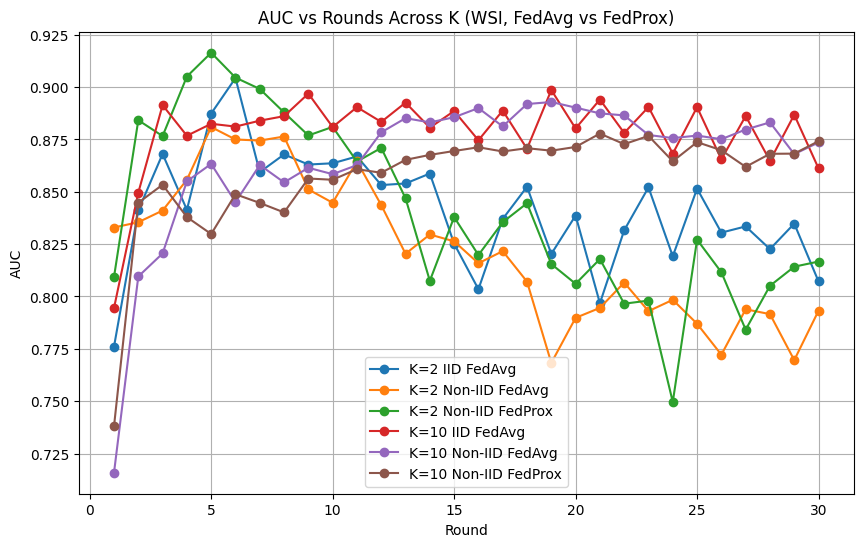

In [28]:
import matplotlib.pyplot as plt

def plot_auc_across_k(results, K_list, title_suffix=""):
    plt.figure(figsize=(10, 6))
    for K in K_list:
        rounds = results[K]["hist_iid"]["round"]
        plt.plot(rounds, results[K]["hist_iid"]["auc"], marker="o", label=f"K={K} IID FedAvg")
        plt.plot(rounds, results[K]["hist_noniid"]["auc"], marker="o", label=f"K={K} Non-IID FedAvg")
        plt.plot(rounds, results[K]["hist_fedprox"]["auc"], marker="o", label=f"K={K} Non-IID FedProx")
    plt.title(f"AUC vs Rounds Across K {title_suffix}".strip())
    plt.xlabel("Round")
    plt.ylabel("AUC")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_auc_across_k(results, K_list=[2, 10], title_suffix="(WSI, FedAvg vs FedProx)")

#### AUC Curves Per K (Cleaner Comparison Within Each K)

We plot AUC vs rounds separately for each K to clearly compare:
- IID FedAvg
- Non-IID FedAvg
- Non-IID FedProx

This makes it easier to interpret within a fixed client count.

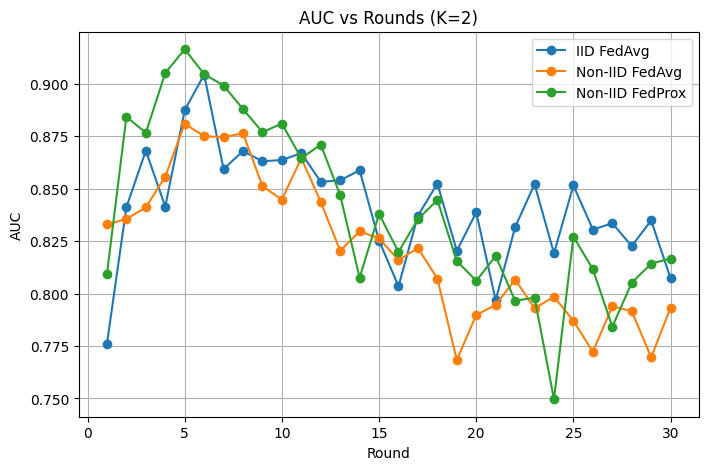

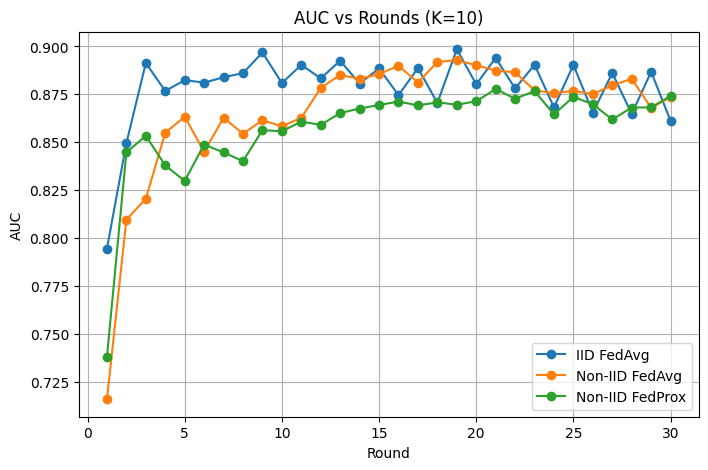

In [29]:
def plot_auc_per_k(results, K):
    rounds = results[K]["hist_iid"]["round"]
    plt.figure(figsize=(8, 5))
    plt.plot(rounds, results[K]["hist_iid"]["auc"], marker="o", label="IID FedAvg")
    plt.plot(rounds, results[K]["hist_noniid"]["auc"], marker="o", label="Non-IID FedAvg")
    plt.plot(rounds, results[K]["hist_fedprox"]["auc"], marker="o", label="Non-IID FedProx")
    plt.title(f"AUC vs Rounds (K={K})")
    plt.xlabel("Round")
    plt.ylabel("AUC")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_auc_per_k(results, K=2)
plot_auc_per_k(results, K=10)

#### Plot Loss and Accuracy Across K (2 vs 10)

We now visualize:
- **Loss vs Rounds**
- **Accuracy vs Rounds**

for different client settings (K = 2 and K = 10).

For each K, we compare:
- IID (FedAvg)
- Non-IID (FedAvg)
- Non-IID (FedProx)

These plots help us analyze:
- Optimization stability (loss)
- Predictive performance (accuracy)
- Effect of client heterogeneity and scale

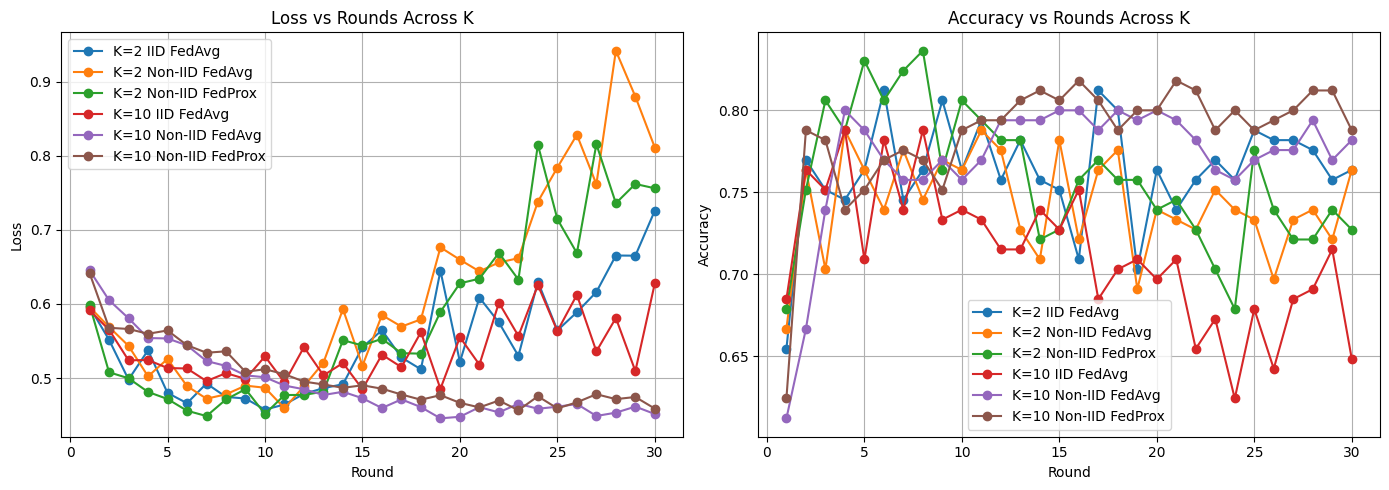

In [30]:
def plot_loss_acc_across_k(results, K_list):
    plt.figure(figsize=(14, 5))

    # -------- LOSS --------
    plt.subplot(1, 2, 1)
    for K in K_list:
        rounds = results[K]["hist_iid"]["round"]
        plt.plot(rounds, results[K]["hist_iid"]["loss"], marker="o", label=f"K={K} IID FedAvg")
        plt.plot(rounds, results[K]["hist_noniid"]["loss"], marker="o", label=f"K={K} Non-IID FedAvg")
        plt.plot(rounds, results[K]["hist_fedprox"]["loss"], marker="o", label=f"K={K} Non-IID FedProx")
    plt.title("Loss vs Rounds Across K")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # -------- ACCURACY --------
    plt.subplot(1, 2, 2)
    for K in K_list:
        rounds = results[K]["hist_iid"]["round"]
        plt.plot(rounds, results[K]["hist_iid"]["acc"], marker="o", label=f"K={K} IID FedAvg")
        plt.plot(rounds, results[K]["hist_noniid"]["acc"], marker="o", label=f"K={K} Non-IID FedAvg")
        plt.plot(rounds, results[K]["hist_fedprox"]["acc"], marker="o", label=f"K={K} Non-IID FedProx")
    plt.title("Accuracy vs Rounds Across K")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run it
plot_loss_acc_across_k(results, K_list=[2, 10])

#### Loss and Accuracy Per K (Cleaner Visualization)

We plot loss and accuracy separately for each K to clearly compare:
- IID FedAvg
- Non-IID FedAvg
- Non-IID FedProx

These figures are better suited for inclusion in reports or publications.

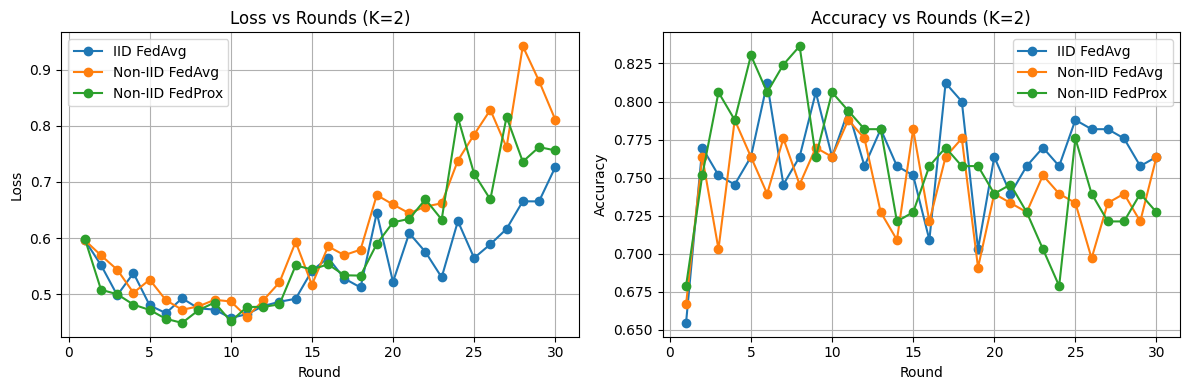

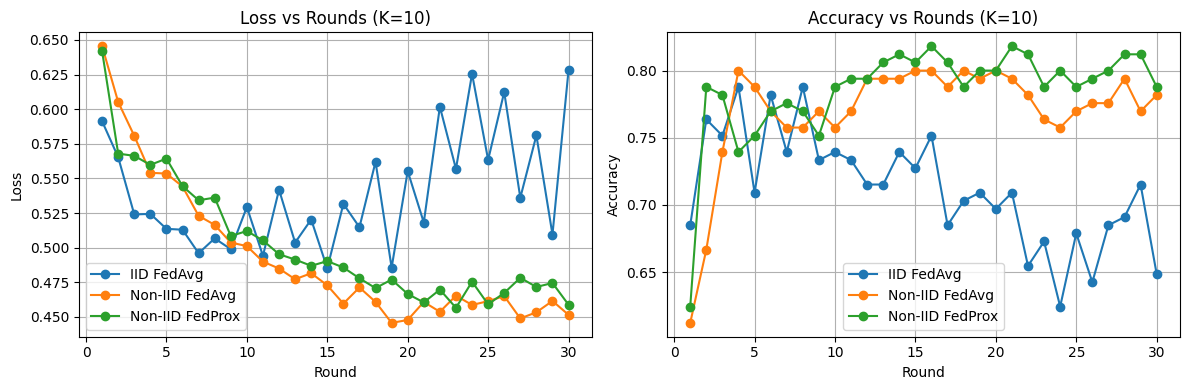

In [31]:
def plot_loss_acc_per_k(results, K):
    rounds = results[K]["hist_iid"]["round"]

    plt.figure(figsize=(12, 4))

    # LOSS
    plt.subplot(1, 2, 1)
    plt.plot(rounds, results[K]["hist_iid"]["loss"], marker="o", label="IID FedAvg")
    plt.plot(rounds, results[K]["hist_noniid"]["loss"], marker="o", label="Non-IID FedAvg")
    plt.plot(rounds, results[K]["hist_fedprox"]["loss"], marker="o", label="Non-IID FedProx")
    plt.title(f"Loss vs Rounds (K={K})")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # ACCURACY
    plt.subplot(1, 2, 2)
    plt.plot(rounds, results[K]["hist_iid"]["acc"], marker="o", label="IID FedAvg")
    plt.plot(rounds, results[K]["hist_noniid"]["acc"], marker="o", label="Non-IID FedAvg")
    plt.plot(rounds, results[K]["hist_fedprox"]["acc"], marker="o", label="Non-IID FedProx")
    plt.title(f"Accuracy vs Rounds (K={K})")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run per K
plot_loss_acc_per_k(results, K=2)
plot_loss_acc_per_k(results, K=10)

# Step M1: Define a Modality Loader (RNA, Methylation, Clinical)

We create a reusable loader that:
1. Loads preprocessed feature matrices for a selected modality
2. Loads patient IDs for that modality
3. Aligns labels using the global RNA-based patient split (same labels used across experiments)
4. Returns `(X_train, y_train, X_test, y_test)` ready for federated client splitting

This ensures all modalities are processed consistently and comparably.

In [32]:
def load_and_align_modality(modality: str, base: Path):
    """
    Returns aligned X_train, y_train, X_test, y_test for the given modality.
    modality ∈ {"rna", "meth", "clin"}
    """
    # shared labels + label patient IDs (global split)
    y_train_full = np.load(base / "rna" / "rna_y_train.npy").astype(np.int64)
    y_test_full  = np.load(base / "rna" / "rna_y_test.npy").astype(np.int64)
    label_pid_train = np.load(base / "rna" / "rna_train_patient_ids.npy", allow_pickle=True).astype(str)
    label_pid_test  = np.load(base / "rna" / "rna_test_patient_ids.npy",  allow_pickle=True).astype(str)

    # modality file mapping
    mod_paths = {
        "rna": {
            "train_X": base / "rna" / "rna_train_pca.npy",
            "test_X":  base / "rna" / "rna_test_pca.npy",
            "train_pid": base / "rna" / "rna_train_patient_ids.npy",
            "test_pid":  base / "rna" / "rna_test_patient_ids.npy",
        },
        "meth": {
            "train_X": base / "methylation" / "meth_train_pca.npy",
            "test_X":  base / "methylation" / "meth_test_pca.npy",
            "train_pid": base / "methylation" / "meth_train_patient_ids.npy",
            "test_pid":  base / "methylation" / "meth_test_patient_ids.npy",
        },
        "clin": {
            "train_X": base / "clinical" / "clin_train_scaled.npy",
            "test_X":  base / "clinical" / "clin_test_scaled.npy",
            # If you later add clinical PID files, swap these:
            "train_pid": base / "rna" / "rna_train_patient_ids.npy",
            "test_pid":  base / "rna" / "rna_test_patient_ids.npy",
        },
    }

    if modality not in mod_paths:
        raise ValueError(f"Unknown modality: {modality}")

    p = mod_paths[modality]
    for k, fp in p.items():
        if not Path(fp).exists():
            raise FileNotFoundError(f"Missing file for {modality}: {k} -> {fp}")

    X_train = np.load(p["train_X"]).astype(np.float32)
    X_test  = np.load(p["test_X"]).astype(np.float32)
    pid_train = np.load(p["train_pid"], allow_pickle=True).astype(str)
    pid_test  = np.load(p["test_pid"],  allow_pickle=True).astype(str)

    # Safety trim (handles any pid length mismatch)
    pid_train = pid_train[: X_train.shape[0]]
    pid_test  = pid_test[: X_test.shape[0]]

    # Align labels to modality patients (keeps only patients present in modality)
    train_label_map = {pp: int(yy) for pp, yy in zip(label_pid_train, y_train_full)}
    test_label_map  = {pp: int(yy) for pp, yy in zip(label_pid_test,  y_test_full)}

    train_keep = np.array([pp in train_label_map for pp in pid_train])
    test_keep  = np.array([pp in test_label_map  for pp in pid_test])

    X_train = X_train[train_keep]
    pid_train = pid_train[train_keep]
    y_train = np.array([train_label_map[pp] for pp in pid_train], dtype=np.int64)

    X_test = X_test[test_keep]
    pid_test = pid_test[test_keep]
    y_test = np.array([test_label_map[pp] for pp in pid_test], dtype=np.int64)

    return X_train, y_train, X_test, y_test

## Step M2: Run the Full Federated Pipeline for RNA, Methylation, and Clinical (All at Once)

We now loop over the three remaining modalities:
- RNA (PCA)
- DNA methylation (PCA)
- Clinical (scaled)

For each modality, we run experiments across:
- K = 2, 5, 10 clients
- IID FedAvg
- Non-IID FedAvg (Dirichlet α = 0.5)
- Non-IID FedProx (μ = 0.01)

We store all outputs in a nested dictionary:
`all_results[modality][K] = {histories + final metrics}`

In [33]:
MODALITIES = ["rna", "meth", "clin"]
K_list = [2, 5, 10]

BASE = Path("/home/steps4growth/gmriechi/Lung-Cancer-Subtyping/Data/02_preprocessed")

ALPHA = 0.5
MU = 1e-2
ROUNDS = 30
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
LR = 1e-3
DROPOUT = 0.2

all_results = {}  # all_results[modality][K] = ...

for modality in MODALITIES:
    print("\n" + "#"*80)
    print(f"MODALITY: {modality.upper()}")
    print("#"*80)

    X_train_m, y_train_m, X_test_m, y_test_m = load_and_align_modality(modality, BASE)
    print("Train:", X_train_m.shape, y_train_m.shape)
    print("Test :", X_test_m.shape,  y_test_m.shape)
    print("Train class counts:", dict(zip(*np.unique(y_train_m, return_counts=True))))

    all_results[modality] = {}

    for K in K_list:
        print("\n" + "="*70)
        print(f"Running {modality.upper()} experiments for K = {K}")
        print("="*70)

        # IID
        clients_iid = make_iid_stratified_clients(X_train_m, y_train_m, num_clients=K, seed=42)
        client_ds_iid, client_sizes_iid = build_client_datasets(clients_iid, batch_size=BATCH_SIZE)

        print(f"\n--- FedAvg (IID, K={K}) ---")
        _, hist_iid = run_fedavg(
            clients_ds=client_ds_iid,
            clients_sizes=client_sizes_iid,
            X_test=X_test_m,
            y_test=y_test_m,
            rounds=ROUNDS,
            local_epochs=LOCAL_EPOCHS,
            lr=LR,
            dropout=DROPOUT
        )

        # Non-IID
        clients_noniid = make_non_iid_dirichlet_clients(X_train_m, y_train_m, num_clients=K, alpha=ALPHA, seed=42)
        client_ds_noniid, client_sizes_noniid = build_client_datasets(clients_noniid, batch_size=BATCH_SIZE)

        print(f"\n--- FedAvg (Non-IID α={ALPHA}, K={K}) ---")
        _, hist_noniid = run_fedavg(
            clients_ds=client_ds_noniid,
            clients_sizes=client_sizes_noniid,
            X_test=X_test_m,
            y_test=y_test_m,
            rounds=ROUNDS,
            local_epochs=LOCAL_EPOCHS,
            lr=LR,
            dropout=DROPOUT
        )

        print(f"\n--- FedProx (Non-IID α={ALPHA}, μ={MU}, K={K}) ---")
        _, hist_fedprox = run_fedprox(
            clients_ds=client_ds_noniid,
            clients_sizes=client_sizes_noniid,
            X_test=X_test_m,
            y_test=y_test_m,
            rounds=ROUNDS,
            local_epochs=LOCAL_EPOCHS,
            lr=LR,
            dropout=DROPOUT,
            mu=MU
        )

        all_results[modality][K] = {
            "hist_iid": hist_iid,
            "hist_noniid": hist_noniid,
            "hist_fedprox": hist_fedprox,
            "final": {
                "iid": {
                    "loss": hist_iid["loss"][-1],
                    "acc":  hist_iid["acc"][-1],
                    "auc":  hist_iid["auc"][-1],
                },
                "noniid_fedavg": {
                    "loss": hist_noniid["loss"][-1],
                    "acc":  hist_noniid["acc"][-1],
                    "auc":  hist_noniid["auc"][-1],
                },
                "noniid_fedprox": {
                    "loss": hist_fedprox["loss"][-1],
                    "acc":  hist_fedprox["acc"][-1],
                    "auc":  hist_fedprox["auc"][-1],
                },
            }
        }

print("\nFinished all modalities.")


################################################################################
MODALITY: RNA
################################################################################
Train: (660, 278) (660,)
Test : (165, 278) (165,)
Train class counts: {np.int64(0): np.int64(364), np.int64(1): np.int64(296)}

Running RNA experiments for K = 2

--- FedAvg (IID, K=2) ---
Round 01/30 | loss=0.2583 | acc=0.9333 | auc=0.9751
Round 02/30 | loss=0.2272 | acc=0.9515 | auc=0.9806
Round 03/30 | loss=0.2819 | acc=0.9394 | auc=0.9739
Round 04/30 | loss=0.2695 | acc=0.9576 | auc=0.9700
Round 05/30 | loss=0.2848 | acc=0.9515 | auc=0.9658
Round 06/30 | loss=0.2757 | acc=0.9636 | auc=0.9651
Round 07/30 | loss=0.3569 | acc=0.9394 | auc=0.9751
Round 08/30 | loss=0.3163 | acc=0.9515 | auc=0.9766
Round 09/30 | loss=0.3484 | acc=0.9455 | auc=0.9766
Round 10/30 | loss=0.3925 | acc=0.9576 | auc=0.9775
Round 11/30 | loss=0.3696 | acc=0.9636 | auc=0.9725
Round 12/30 | loss=0.4074 | acc=0.9455 | auc=0.9769


Round 13/30 | loss=0.4637 | acc=0.9455 | auc=0.9716
Round 14/30 | loss=0.4753 | acc=0.9455 | auc=0.9771
Round 15/30 | loss=0.4714 | acc=0.9515 | auc=0.9716
Round 16/30 | loss=0.4905 | acc=0.9455 | auc=0.9725
Round 17/30 | loss=0.4890 | acc=0.9515 | auc=0.9721
Round 18/30 | loss=0.4320 | acc=0.9636 | auc=0.9673
Round 19/30 | loss=0.5799 | acc=0.9394 | auc=0.9642
Round 20/30 | loss=0.4928 | acc=0.9515 | auc=0.9669
Round 21/30 | loss=0.5192 | acc=0.9394 | auc=0.9773
Round 22/30 | loss=0.4989 | acc=0.9394 | auc=0.9723
Round 23/30 | loss=0.5405 | acc=0.9394 | auc=0.9723
Round 24/30 | loss=0.5446 | acc=0.9455 | auc=0.9723
Round 25/30 | loss=0.5547 | acc=0.9394 | auc=0.9723
Round 26/30 | loss=0.5824 | acc=0.9394 | auc=0.9669
Round 27/30 | loss=0.6277 | acc=0.9455 | auc=0.9608
Round 28/30 | loss=0.6506 | acc=0.9455 | auc=0.9592
Round 29/30 | loss=0.5440 | acc=0.9576 | auc=0.9676
Round 30/30 | loss=0.5258 | acc=0.9576 | auc=0.9676

--- FedAvg (Non-IID α=0.5, K=2) ---
Round 01/30 | loss=0.2822 |

2026-02-22 10:56:58.670920: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 01/30 | loss=0.3608 | acc=0.9515 | auc=0.9594
Round 02/30 | loss=0.3076 | acc=0.9455 | auc=0.9558
Round 03/30 | loss=0.2878 | acc=0.9515 | auc=0.9750
Round 04/30 | loss=0.3192 | acc=0.9333 | auc=0.9677
Round 05/30 | loss=0.3122 | acc=0.9515 | auc=0.9632
Round 06/30 | loss=0.2829 | acc=0.9455 | auc=0.9696
Round 07/30 | loss=0.3668 | acc=0.9333 | auc=0.9768
Round 08/30 | loss=0.3734 | acc=0.9515 | auc=0.9609
Round 09/30 | loss=0.3593 | acc=0.9455 | auc=0.9707
Round 10/30 | loss=0.3627 | acc=0.9455 | auc=0.9704
Round 11/30 | loss=0.4084 | acc=0.9394 | auc=0.9672
Round 12/30 | loss=0.4164 | acc=0.9576 | auc=0.9655
Round 13/30 | loss=0.5075 | acc=0.9394 | auc=0.9656
Round 14/30 | loss=0.4695 | acc=0.9515 | auc=0.9707
Round 15/30 | loss=0.4582 | acc=0.9576 | auc=0.9670
Round 16/30 | loss=0.5126 | acc=0.9455 | auc=0.9655
Round 17/30 | loss=0.4547 | acc=0.9515 | auc=0.9675
Round 18/30 | loss=0.5164 | acc=0.9455 | auc=0.9593
Round 19/30 | loss=0.4225 | acc=0.9576 | auc=0.9678
Round 20/30 

2026-02-22 11:14:10.156083: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 02/30 | loss=0.4706 | acc=0.9636 | auc=0.9642
Round 03/30 | loss=0.3950 | acc=0.9576 | auc=0.9774
Round 04/30 | loss=0.4455 | acc=0.9576 | auc=0.9660
Round 05/30 | loss=0.7983 | acc=0.9455 | auc=0.9552
Round 06/30 | loss=0.5788 | acc=0.9576 | auc=0.9604
Round 07/30 | loss=0.7220 | acc=0.9515 | auc=0.9543
Round 08/30 | loss=0.4240 | acc=0.9697 | auc=0.9679
Round 09/30 | loss=0.7749 | acc=0.9576 | auc=0.9547
Round 10/30 | loss=0.7440 | acc=0.9515 | auc=0.9665
Round 11/30 | loss=0.8228 | acc=0.9455 | auc=0.9667
Round 12/30 | loss=0.9632 | acc=0.9515 | auc=0.9668
Round 13/30 | loss=1.0635 | acc=0.9515 | auc=0.9605
Round 14/30 | loss=1.2592 | acc=0.9455 | auc=0.9547
Round 15/30 | loss=1.0258 | acc=0.9455 | auc=0.9550
Round 16/30 | loss=1.0311 | acc=0.9636 | auc=0.9654
Round 17/30 | loss=0.9777 | acc=0.9515 | auc=0.9599
Round 18/30 | loss=0.9268 | acc=0.9576 | auc=0.9655
Round 19/30 | loss=1.1536 | acc=0.9515 | auc=0.9548
Round 20/30 | loss=1.1477 | acc=0.9515 | auc=0.9548
Round 21/30 

## Step M3: Combined Summary Table Across Modalities and K

We print a single consolidated table containing:
- modality
- K
- IID FedAvg final metrics
- Non-IID FedAvg final metrics
- Non-IID FedProx final metrics

In [34]:
all_results['wsi'] = results

In [35]:
print("FINAL METRICS SUMMARY (Test set, Round 30)\n")
print("modality | K | setting | loss | acc | auc")
print("-"*70)

for modality in all_results:
    for K in all_results[modality]:
        f = all_results[modality][K]["final"]
        print(f"{modality:>7} | {K:>2} | IID (FedAvg)      | {f['iid']['loss']:.4f} | {f['iid']['acc']:.4f} | {f['iid']['auc']:.4f}")
        print(f"{modality:>7} | {K:>2} | Non-IID (FedAvg)  | {f['noniid_fedavg']['loss']:.4f} | {f['noniid_fedavg']['acc']:.4f} | {f['noniid_fedavg']['auc']:.4f}")
        print(f"{modality:>7} | {K:>2} | Non-IID (FedProx) | {f['noniid_fedprox']['loss']:.4f} | {f['noniid_fedprox']['acc']:.4f} | {f['noniid_fedprox']['auc']:.4f}")
        print("-"*70)

FINAL METRICS SUMMARY (Test set, Round 30)

modality | K | setting | loss | acc | auc
----------------------------------------------------------------------
    rna |  2 | IID (FedAvg)      | 0.5258 | 0.9576 | 0.9676
    rna |  2 | Non-IID (FedAvg)  | 0.6717 | 0.9515 | 0.9546
    rna |  2 | Non-IID (FedProx) | 0.4529 | 0.9576 | 0.9730
----------------------------------------------------------------------
    rna |  5 | IID (FedAvg)      | 0.4914 | 0.9515 | 0.9673
    rna |  5 | Non-IID (FedAvg)  | 0.4304 | 0.9455 | 0.9661
    rna |  5 | Non-IID (FedProx) | 0.4732 | 0.9515 | 0.9721
----------------------------------------------------------------------
    rna | 10 | IID (FedAvg)      | 0.2824 | 0.9576 | 0.9784
    rna | 10 | Non-IID (FedAvg)  | 0.4800 | 0.9576 | 0.9641
    rna | 10 | Non-IID (FedProx) | 0.3872 | 0.9576 | 0.9725
----------------------------------------------------------------------
   meth |  2 | IID (FedAvg)      | 1.3036 | 0.9455 | 0.9623
   meth |  2 | Non-IID (FedAvg

In [36]:
print(all_results.keys())

dict_keys(['rna', 'meth', 'clin', 'wsi'])


##### Figure 1: IID Learning Curves (K = 5)

This figure shows the AUC learning curves across federated rounds under an IID client split with **K = 5** clients for all modalities (RNA, DNA methylation, WSI, and clinical).  
Convergence is interpreted as the point where AUC improvements plateau over successive rounds.

In [37]:
# List candidate functions available in your current session
candidates = [n for n in globals().keys()
              if ("dirich" in n.lower() or "noniid" in n.lower())
              and callable(globals()[n])]
candidates

['make_non_iid_dirichlet_clients', 'global_model_noniid', 'model_noniid']

In [38]:
K = 5
ROUNDS = 30
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
ALPHA = 0.5
MU = 0.01

# 1) Create client splits (use your real function names)
clients_iid = make_iid_stratified_clients(X_train, y_train, num_clients=K, seed=42)
clients_noniid = make_non_iid_dirichlet_clients(X_train, y_train, num_clients=K, alpha=ALPHA, seed=42)

# 2) Build tf.data datasets (your function)
client_ds_iid, client_sizes_iid = build_client_datasets(clients_iid, batch_size=BATCH_SIZE)
client_ds_noniid, client_sizes_noniid = build_client_datasets(clients_noniid, batch_size=BATCH_SIZE)

print("✅ WSI client datasets created for K=5")
print("IID sizes:", client_sizes_iid)
print("Non-IID sizes:", client_sizes_noniid)

# 3) Train FedAvg under IID
global_model_iid, hist_iid = run_fedavg(
    clients_ds=client_ds_iid,
    clients_sizes=client_sizes_iid,
    X_test=X_test,
    y_test=y_test,
    rounds=ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    lr=1e-3,
    dropout=0.2
)

# 4) Train FedAvg under Non-IID
global_model_noniid, hist_noniid = run_fedavg(
    clients_ds=client_ds_noniid,
    clients_sizes=client_sizes_noniid,
    X_test=X_test,
    y_test=y_test,
    rounds=ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    lr=1e-3,
    dropout=0.2
)

# 5) Train FedProx under Non-IID
global_model_fedprox, hist_fedprox = run_fedprox(
    clients_ds=client_ds_noniid,
    clients_sizes=client_sizes_noniid,
    X_test=X_test,
    y_test=y_test,
    rounds=ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    lr=1e-3,
    dropout=0.2,
    mu=MU
)

# 6) Save into all_results['wsi'][5]
if "wsi" not in all_results:
    all_results["wsi"] = {}

all_results["wsi"][K] = {
    "hist_iid": hist_iid,
    "hist_noniid": hist_noniid,
    "hist_fedprox": hist_fedprox
}

print("Saved WSI K=5 into all_results['wsi'][5]")
print("WSI K keys now:", sorted(all_results["wsi"].keys()))

✅ WSI client datasets created for K=5
IID sizes: {0: 132, 1: 132, 2: 132, 3: 131, 4: 131}
Non-IID sizes: {0: 143, 1: 212, 2: 112, 3: 99, 4: 92}
Round 01/30 | loss=0.6379 | acc=0.6545 | auc=0.7129
Round 02/30 | loss=0.5988 | acc=0.7152 | auc=0.7947
Round 03/30 | loss=0.5703 | acc=0.7273 | auc=0.8065
Round 04/30 | loss=0.5565 | acc=0.6970 | auc=0.8211
Round 05/30 | loss=0.5357 | acc=0.7576 | auc=0.8303
Round 06/30 | loss=0.5164 | acc=0.7636 | auc=0.8493
Round 07/30 | loss=0.5032 | acc=0.7939 | auc=0.8689
Round 08/30 | loss=0.4840 | acc=0.7879 | auc=0.8756
Round 09/30 | loss=0.4773 | acc=0.7818 | auc=0.8817
Round 10/30 | loss=0.4753 | acc=0.7758 | auc=0.8783
Round 11/30 | loss=0.4801 | acc=0.8182 | auc=0.8722
Round 12/30 | loss=0.4656 | acc=0.8061 | auc=0.8909
Round 13/30 | loss=0.4788 | acc=0.8182 | auc=0.8762
Round 14/30 | loss=0.4301 | acc=0.7939 | auc=0.8946
Round 15/30 | loss=0.4269 | acc=0.8242 | auc=0.8972
Round 16/30 | loss=0.4862 | acc=0.8000 | auc=0.8791
Round 17/30 | loss=0.531

2026-02-22 11:54:25.333473: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 02/30 | loss=0.5758 | acc=0.7212 | auc=0.8383
Round 03/30 | loss=0.5672 | acc=0.7273 | auc=0.8707
Round 04/30 | loss=0.5516 | acc=0.7879 | auc=0.8713
Round 05/30 | loss=0.5512 | acc=0.7394 | auc=0.8640
Round 06/30 | loss=0.5386 | acc=0.7939 | auc=0.8542
Round 07/30 | loss=0.5137 | acc=0.8182 | auc=0.8735
Round 08/30 | loss=0.5121 | acc=0.7758 | auc=0.8677
Round 09/30 | loss=0.5156 | acc=0.8182 | auc=0.8713
Round 10/30 | loss=0.5157 | acc=0.7152 | auc=0.8715
Round 11/30 | loss=0.4949 | acc=0.8000 | auc=0.8699
Round 12/30 | loss=0.4692 | acc=0.8182 | auc=0.8853
Round 13/30 | loss=0.4725 | acc=0.8485 | auc=0.8761
Round 14/30 | loss=0.5080 | acc=0.7576 | auc=0.8568
Round 15/30 | loss=0.4929 | acc=0.8121 | auc=0.8596
Round 16/30 | loss=0.4891 | acc=0.7879 | auc=0.8655
Round 17/30 | loss=0.4910 | acc=0.8000 | auc=0.8605
Round 18/30 | loss=0.4715 | acc=0.8000 | auc=0.8808
Round 19/30 | loss=0.4836 | acc=0.7939 | auc=0.8611
Round 20/30 | loss=0.4557 | acc=0.8000 | auc=0.8770
Round 21/30 

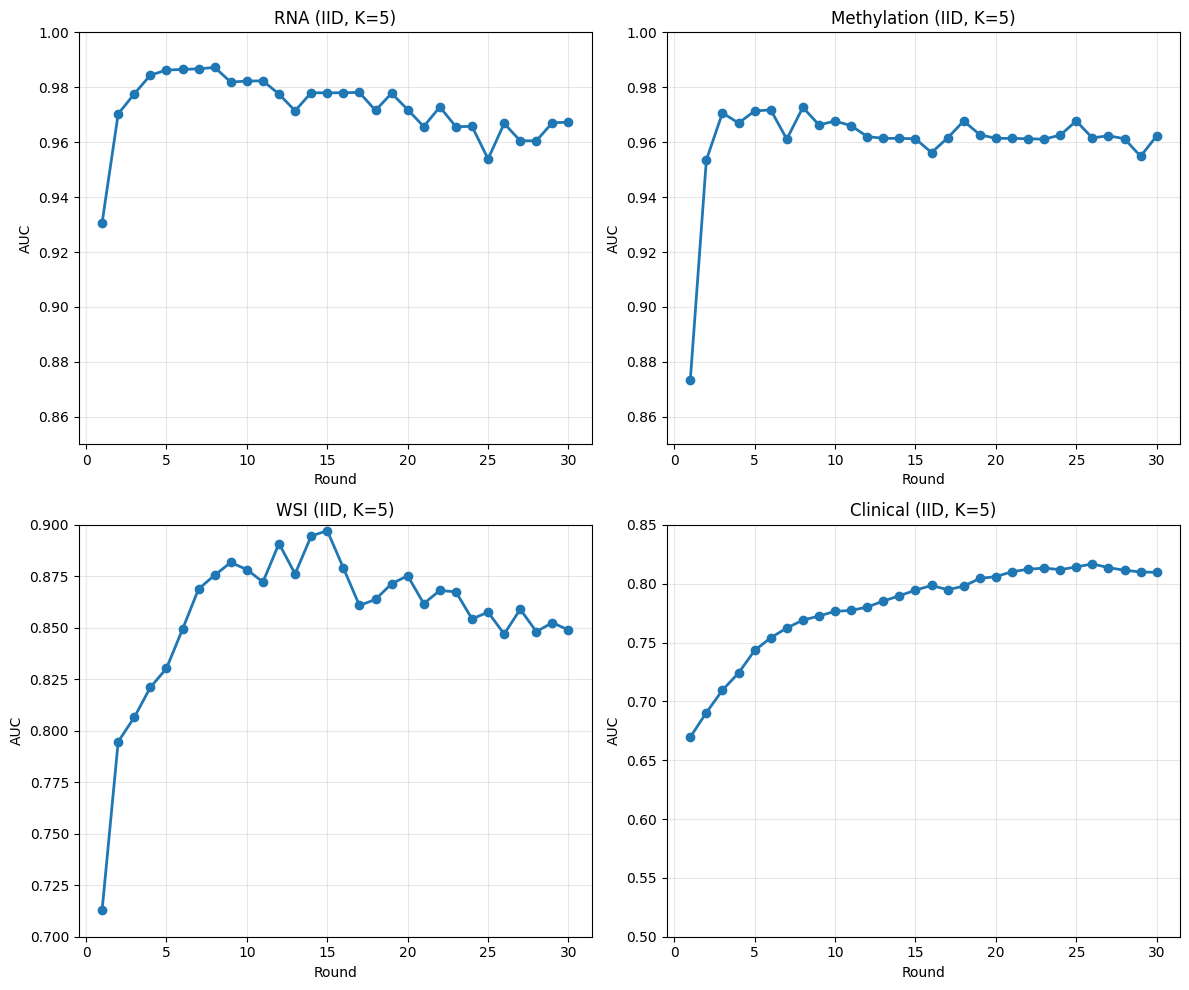

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modalities = [
    ("RNA",  "rna"),
    ("Methylation", "meth"),
    ("WSI",  "wsi"),
    ("Clinical", "clin"),
]
K = 5

for (label, key), ax in zip(modalities, axes.flat):
    rounds = all_results[key][K]["hist_iid"]["round"]
    auc    = all_results[key][K]["hist_iid"]["auc"]

    ax.plot(rounds, auc, marker="o", linewidth=2)
    ax.set_title(f"{label} (IID, K={K})")
    ax.set_xlabel("Round")
    ax.set_ylabel("AUC")
    ax.grid(True, alpha=0.3)

    # Modality-specific limits for readability
    if key == "clin":
        ax.set_ylim([0.5, 0.85])
    elif key == "wsi":
        ax.set_ylim([0.7, 0.9])
    else:
        ax.set_ylim([0.85, 1.0])

plt.tight_layout()
plt.savefig("fig1_iid_learning_curves_K5.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
for m in ['rna', 'meth', 'wsi', 'clin']:
    ks = list(all_results[m].keys())
    print(m, "K keys:", ks, "| types:", [type(k).__name__ for k in ks])

rna K keys: [2, 5, 10] | types: ['int', 'int', 'int']
meth K keys: [2, 5, 10] | types: ['int', 'int', 'int']
wsi K keys: [2, 10, 5] | types: ['int', 'int', 'int']
clin K keys: [2, 5, 10] | types: ['int', 'int', 'int']
